# 02 – Multi-Layer Perceptron (MLP)

Este notebook implementa e avalia modelos MLP para classificação de borboletas (75 classes).

## Experiências realizadas
| Experimento | Arquitectura | Loss | Optimizador |
|-------------|-------------|------|-------------|
| MLP-A-CE-RMS | Pequena (2 hidden) | CrossEntropy | RMSprop |
| MLP-A-CE-ADAM | Pequena (2 hidden) | CrossEntropy | ADAM |
| MLP-A-MM-RMS | Pequena (2 hidden) | MultiMargin | RMSprop |
| MLP-A-MM-ADAM | Pequena (2 hidden) | MultiMargin | ADAM |
| MLP-B-CE-RMS | Grande (4 hidden) | CrossEntropy | RMSprop |
| MLP-B-CE-ADAM | Grande (4 hidden) | CrossEntropy | ADAM |
| MLP-B-MM-RMS | Grande (4 hidden) | MultiMargin | RMSprop |
| MLP-B-MM-ADAM | Grande (4 hidden) | MultiMargin | ADAM |

## 1. Importações e configuração

In [11]:
import os
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, top_k_accuracy_score
)

import kagglehub

# Reproducibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 2. Pipeline de dados

### Justificação das métricas
- **Accuracy**: métrica primária – o dataset está apenas *ligeiramente* desbalanceado (min 57, max 105 imagens/classe), pelo que accuracy é uma proxy razoável para o desempenho global.
- **Macro F1-Score**: média não ponderada por classe – penaliza igualmente erros em classes pequeñas, complementando a accuracy.
- **Top-5 Accuracy**: útil em classificação fine-grained com 75 classes visualmente semelhantes.
- **Confusion matrix**: inspecção qualitativa de padrões de confusão.

In [12]:
# ── Hiperparâmetros globais ──────────────────────────────────────────────────
BATCH_SIZE  = 64
IMAGE_SIZE  = 64          # imagens redimensionadas para 64×64
FLAT_SIZE   = 3 * IMAGE_SIZE * IMAGE_SIZE   # 3×64×64 = 12 288
NUM_CLASSES = 75
NUM_EPOCHS  = 30
LR          = 1e-3
VAL_SPLIT   = 0.2         # 20 % de validação

# ── Download do dataset ──────────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
img_dir   = os.path.join(path, 'train')
train_csv = os.path.join(path, 'train.csv')
print(f'Dataset em: {path}')

df = pd.read_csv(train_csv)
print(f'Total de amostras: {len(df)}  |  Classes: {df["label"].nunique()}')

Dataset em: /Users/matildecarvalho/.cache/kagglehub/competitions/aca-butterflies
Total de amostras: 5199  |  Classes: 75


In [13]:
# ── Mapeamento classe → índice (consistente com 01_data_exploration) ─────────
classes = sorted(df['label'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
print(f'Número de classes: {len(classes)}')

Número de classes: 75


In [14]:
class ButterflyDataset(data.Dataset):
    """Dataset de borboletas para o projeto ACA."""

    def __init__(self, df, img_dir, class_to_idx, transform=None):
        self.img_labels  = df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.class_to_idx = class_to_idx
        self.transform   = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        row = self.img_labels.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Para MLP: normalização + flatten implícito na rede
# Data augmentation apenas no treino
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Train / Validation split ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED,
    stratify=df['label']   # mantém proporção de classes
)
print(f'Treino: {len(df_train)}  | Validação: {len(df_val)}')

train_ds = ButterflyDataset(df_train, img_dir, class_to_idx, train_transform)
val_ds   = ButterflyDataset(df_val,   img_dir, class_to_idx, val_transform)

train_loader = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Batches treino: {len(train_loader)}  |  Batches val: {len(val_loader)}')

Treino: 4159  | Validação: 1040
Batches treino: 65  |  Batches val: 17


## 3. Arquitecturas MLP

### Arquitectura A – MLP Pequeno
Input → 1024 → 512 → 75  (2 camadas escondidas)

### Arquitectura B – MLP Grande  
Input → 2048 → 1024 → 512 → 256 → 75  (4 camadas escondidas)

Ambas usam:
- **ReLU** como activação
- **BatchNorm** após cada camada linear (estabiliza treino)
- **Dropout** para regularização

In [16]:
class MLP(nn.Module):
    """
    MLP genérico configurável.

    Parâmetros
    ----------
    input_size  : dimensão do vector de entrada (FLAT_SIZE = 12 288)
    hidden_dims : lista com o número de neurónios de cada camada escondida
    num_classes : número de classes de saída
    dropout     : probabilidade de dropout
    """
    def __init__(self, input_size, hidden_dims, num_classes, dropout=0.4):
        super().__init__()
        layers = [nn.Flatten()]
        in_dim = input_size
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Arquitecturas ─────────────────────────────────────────────────────────────
ARCH_A = dict(hidden_dims=[1024, 512],           dropout=0.4)   # 2 hidden layers
ARCH_B = dict(hidden_dims=[2048, 1024, 512, 256], dropout=0.4)  # 4 hidden layers

# Teste rápido
dummy = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE)
for name, arch in [('A', ARCH_A), ('B', ARCH_B)]:
    m = MLP(FLAT_SIZE, arch['hidden_dims'], NUM_CLASSES, arch['dropout'])
    out = m(dummy)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'MLP-{name}: output={tuple(out.shape)}  parâmetros={params:,}')

MLP-A: output=(4, 75)  parâmetros=13,150,283
MLP-B: output=(4, 75)  parâmetros=27,949,131


## 4. Função de treino e avaliação

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = correct / total
    loss = total_loss / total
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    top5 = top_k_accuracy_score(all_labels, np.array(all_probs), k=5)
    return loss, acc, f1, top5, all_preds, all_labels


def train_model(arch_name, arch_cfg, loss_name, opt_name,
                num_epochs=NUM_EPOCHS, lr=LR, device=DEVICE):
    """
    Treina um MLP com a arquitectura, loss e optimizador especificados.
    Devolve o histórico e o modelo com melhor val-accuracy.
    """
    print(f'\n{"="*60}')
    print(f' Experimento: MLP-{arch_name} | Loss: {loss_name} | Opt: {opt_name}')
    print(f'{"="*60}')

    # Modelo
    model = MLP(FLAT_SIZE, arch_cfg['hidden_dims'], NUM_CLASSES, arch_cfg['dropout'])
    model = model.to(device)

    # Loss
    if loss_name == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss()
    elif loss_name == 'MultiMargin':
        criterion = nn.MultiMarginLoss()
    else:
        raise ValueError(f'Loss desconhecida: {loss_name}')

    # Optimizador
    if opt_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f'Optimizador desconhecido: {opt_name}')

    # Learning rate scheduler – reduz lr se val_loss estagnar
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'val_f1':     [], 'val_top5':  []}

    best_acc   = 0.0
    best_state = None
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, vl_f1, vl_top5, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)
        history['val_top5'].append(vl_top5)

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Época {epoch:3d}/{num_epochs} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                  f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} F1={vl_f1:.3f} Top5={vl_top5:.3f}')

    elapsed = time.time() - t0
    print(f'  Tempo total: {elapsed:.1f}s  |  Melhor val_acc: {best_acc:.4f}')

    # Carrega melhor modelo
    model.load_state_dict(best_state)
    return model, history, best_acc

## 5. Execução de todos os experimentos

Executamos 8 combinações (2 arquitecturas × 2 losses × 2 optimizadores).

> **Nota:** cada execução treina durante `NUM_EPOCHS` epochs. Para resultados rápidos pode reduzir `NUM_EPOCHS` acima.

In [18]:
EXPERIMENTS = [
    ('A', ARCH_A, 'CrossEntropy', 'RMSprop'),
    ('A', ARCH_A, 'CrossEntropy', 'Adam'),
    ('A', ARCH_A, 'MultiMargin',  'RMSprop'),
    ('A', ARCH_A, 'MultiMargin',  'Adam'),
    ('B', ARCH_B, 'CrossEntropy', 'RMSprop'),
    ('B', ARCH_B, 'CrossEntropy', 'Adam'),
    ('B', ARCH_B, 'MultiMargin',  'RMSprop'),
    ('B', ARCH_B, 'MultiMargin',  'Adam'),
]

results = {}   # guardamos os resultados de cada experimento

for arch_name, arch_cfg, loss_name, opt_name in EXPERIMENTS:
    key = f'MLP-{arch_name}_{loss_name}_{opt_name}'
    model, history, best_acc = train_model(
        arch_name, arch_cfg, loss_name, opt_name
    )
    # Avaliação final com o melhor modelo
    _, vl_acc, vl_f1, vl_top5, preds, labels = evaluate(
        model, val_loader, 
        nn.CrossEntropyLoss() if loss_name == 'CrossEntropy' else nn.MultiMarginLoss(),
        DEVICE
    )
    results[key] = {
        'history'  : history,
        'best_acc' : best_acc,
        'val_acc'  : vl_acc,
        'val_f1'   : vl_f1,
        'val_top5' : vl_top5,
        'preds'    : preds,
        'labels'   : labels,
        'model'    : model,
    }


 Experimento: MLP-A | Loss: CrossEntropy | Opt: RMSprop


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Época   1/30 | TrLoss=3.7883 TrAcc=0.101 | VlLoss=3.1832 VlAcc=0.189 F1=0.146 Top5=0.479


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Época   5/30 | TrLoss=2.4490 TrAcc=0.342 | VlLoss=2.4506 VlAcc=0.376 F1=0.354 Top5=0.669


...

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Época  25/30 | TrLoss=0.1105 TrAcc=0.363 | VlLoss=0.1884 VlAcc=0.344 F1=0.327 Top5=0.694


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Época  30/30 | TrLoss=0.0963 TrAcc=0.380 | VlLoss=0.1834 VlAcc=0.347 F1=0.336 Top5=0.682
  Tempo total: 797.0s  |  Melhor val_acc: 0.3471


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


## 6. Resultados e Comparação

In [19]:
rows = []
for key, r in results.items():
    rows.append({
        'Experimento': key,
        'Val Accuracy':  f"{r['val_acc']:.4f}",
        'Macro F1':      f"{r['val_f1']:.4f}",
        'Top-5 Acc':     f"{r['val_top5']:.4f}",
    })

df_results = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)
df_results

,Experimento,Val Accuracy,Macro F1,Top-5 Acc
0,MLP-A_CrossEntropy_RMSprop,0.4529,0.4499,0.7192
1,MLP-A_CrossEntropy_Adam,0.4481,0.4409,0.7029
5,MLP-B_CrossEntropy_Adam,0.4163,0.4081,0.7154
2,MLP-A_MultiMargin_RMSprop,0.4087,0.4119,0.7144
3,MLP-A_MultiMargin_Adam,0.4058,0.3977,0.6981
4,MLP-B_CrossEntropy_RMSprop,0.4058,0.4040,0.6817
7,MLP-B_MultiMargin_Adam,0.3471,0.3364,0.6817
6,MLP-B_MultiMargin_RMSprop,0.3375,0.3217,0.6779


### 6.1 Curvas de aprendizagem

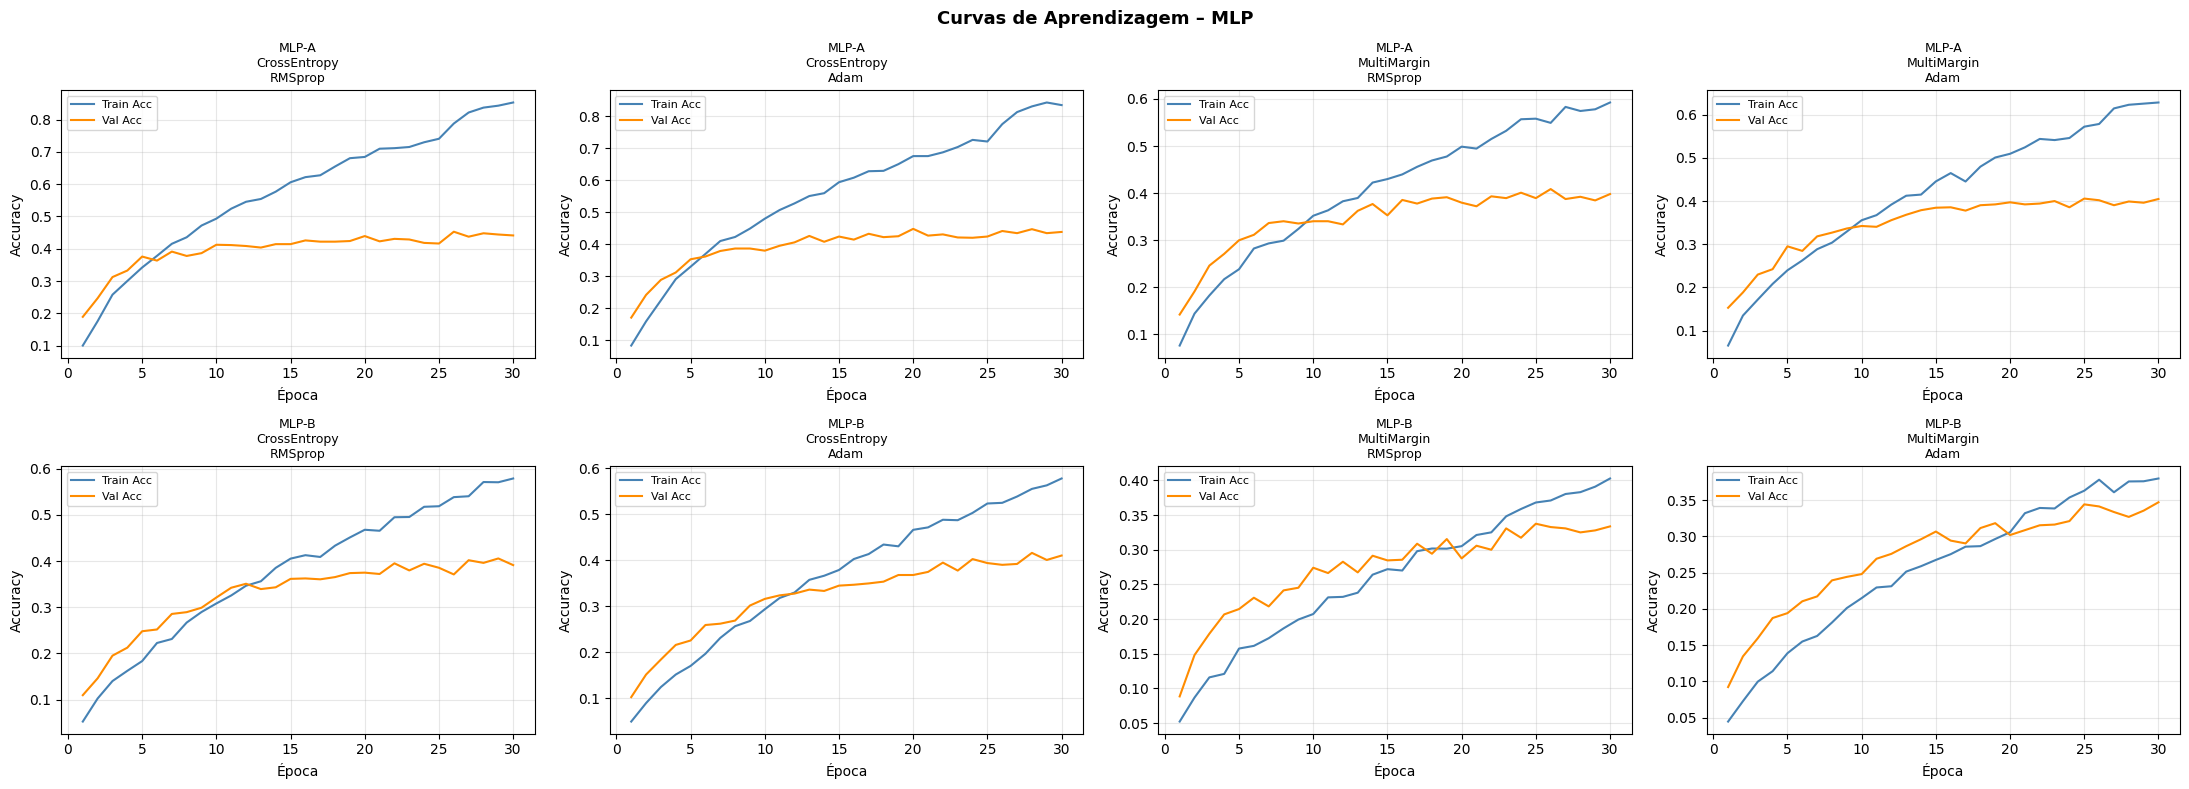

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
axes = axes.flatten()

for ax, (key, r) in zip(axes, results.items()):
    h = r['history']
    epochs = range(1, len(h['train_acc']) + 1)
    ax.plot(epochs, h['train_acc'], label='Train Acc', color='steelblue')
    ax.plot(epochs, h['val_acc'],   label='Val Acc',   color='darkorange')
    ax.set_title(key.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizagem – MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Curvas de loss

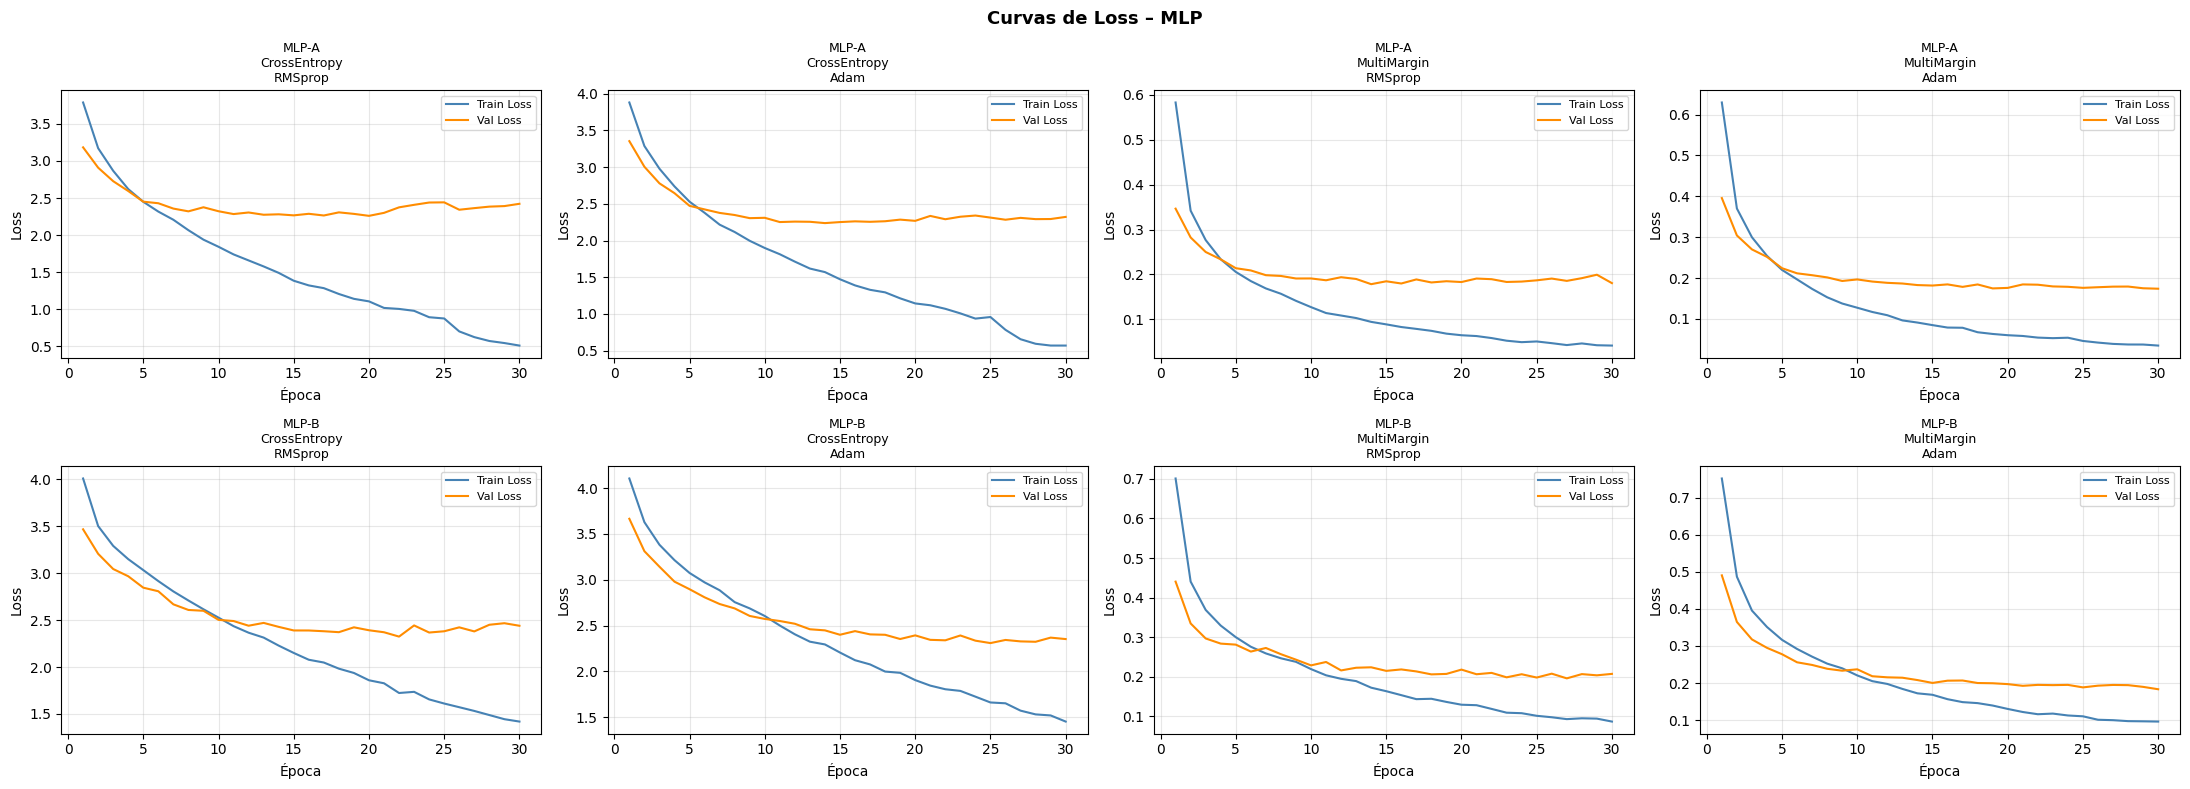

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
axes = axes.flatten()

for ax, (key, r) in zip(axes, results.items()):
    h = r['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(epochs, h['val_loss'],   label='Val Loss',   color='darkorange')
    ax.set_title(key.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Loss – MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Comparação em barra

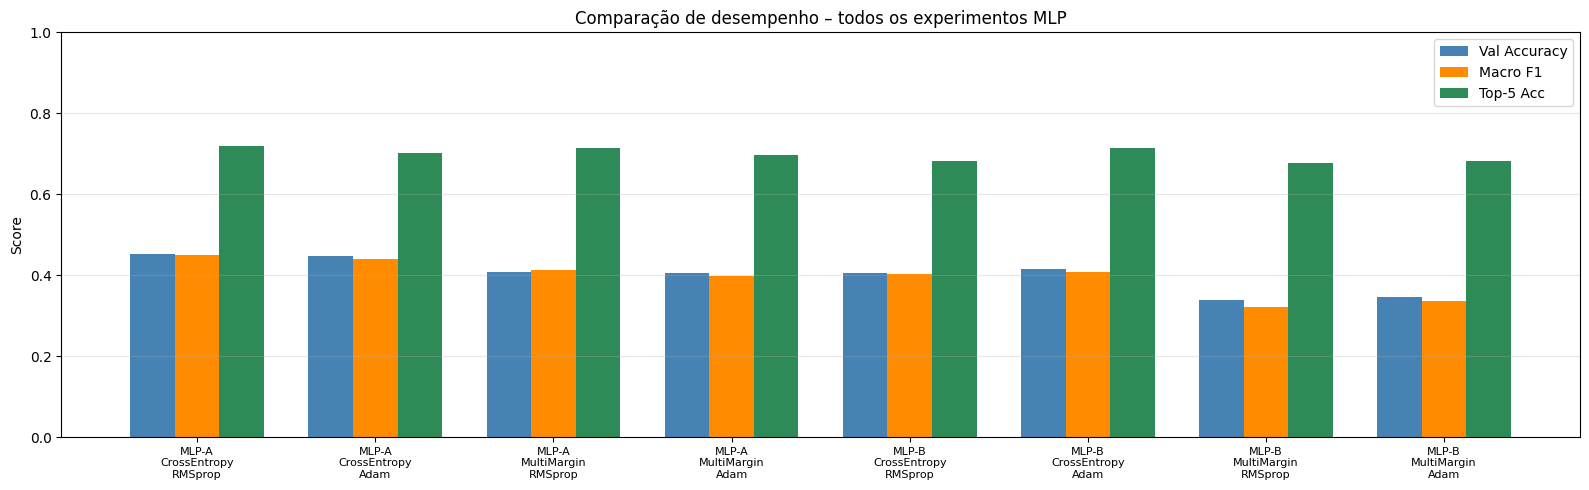

In [22]:
keys   = list(results.keys())
accs   = [results[k]['val_acc']  for k in keys]
f1s    = [results[k]['val_f1']   for k in keys]
top5s  = [results[k]['val_top5'] for k in keys]

x = np.arange(len(keys))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width, accs,  width, label='Val Accuracy', color='steelblue')
ax.bar(x,         f1s,   width, label='Macro F1',     color='darkorange')
ax.bar(x + width, top5s, width, label='Top-5 Acc',    color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels([k.replace('_', '\n') for k in keys], fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Comparação de desempenho – todos os experimentos MLP')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Confusion Matrix – melhor modelo

Melhor experimento: MLP-A_CrossEntropy_RMSprop  |  Val Acc = 0.4529


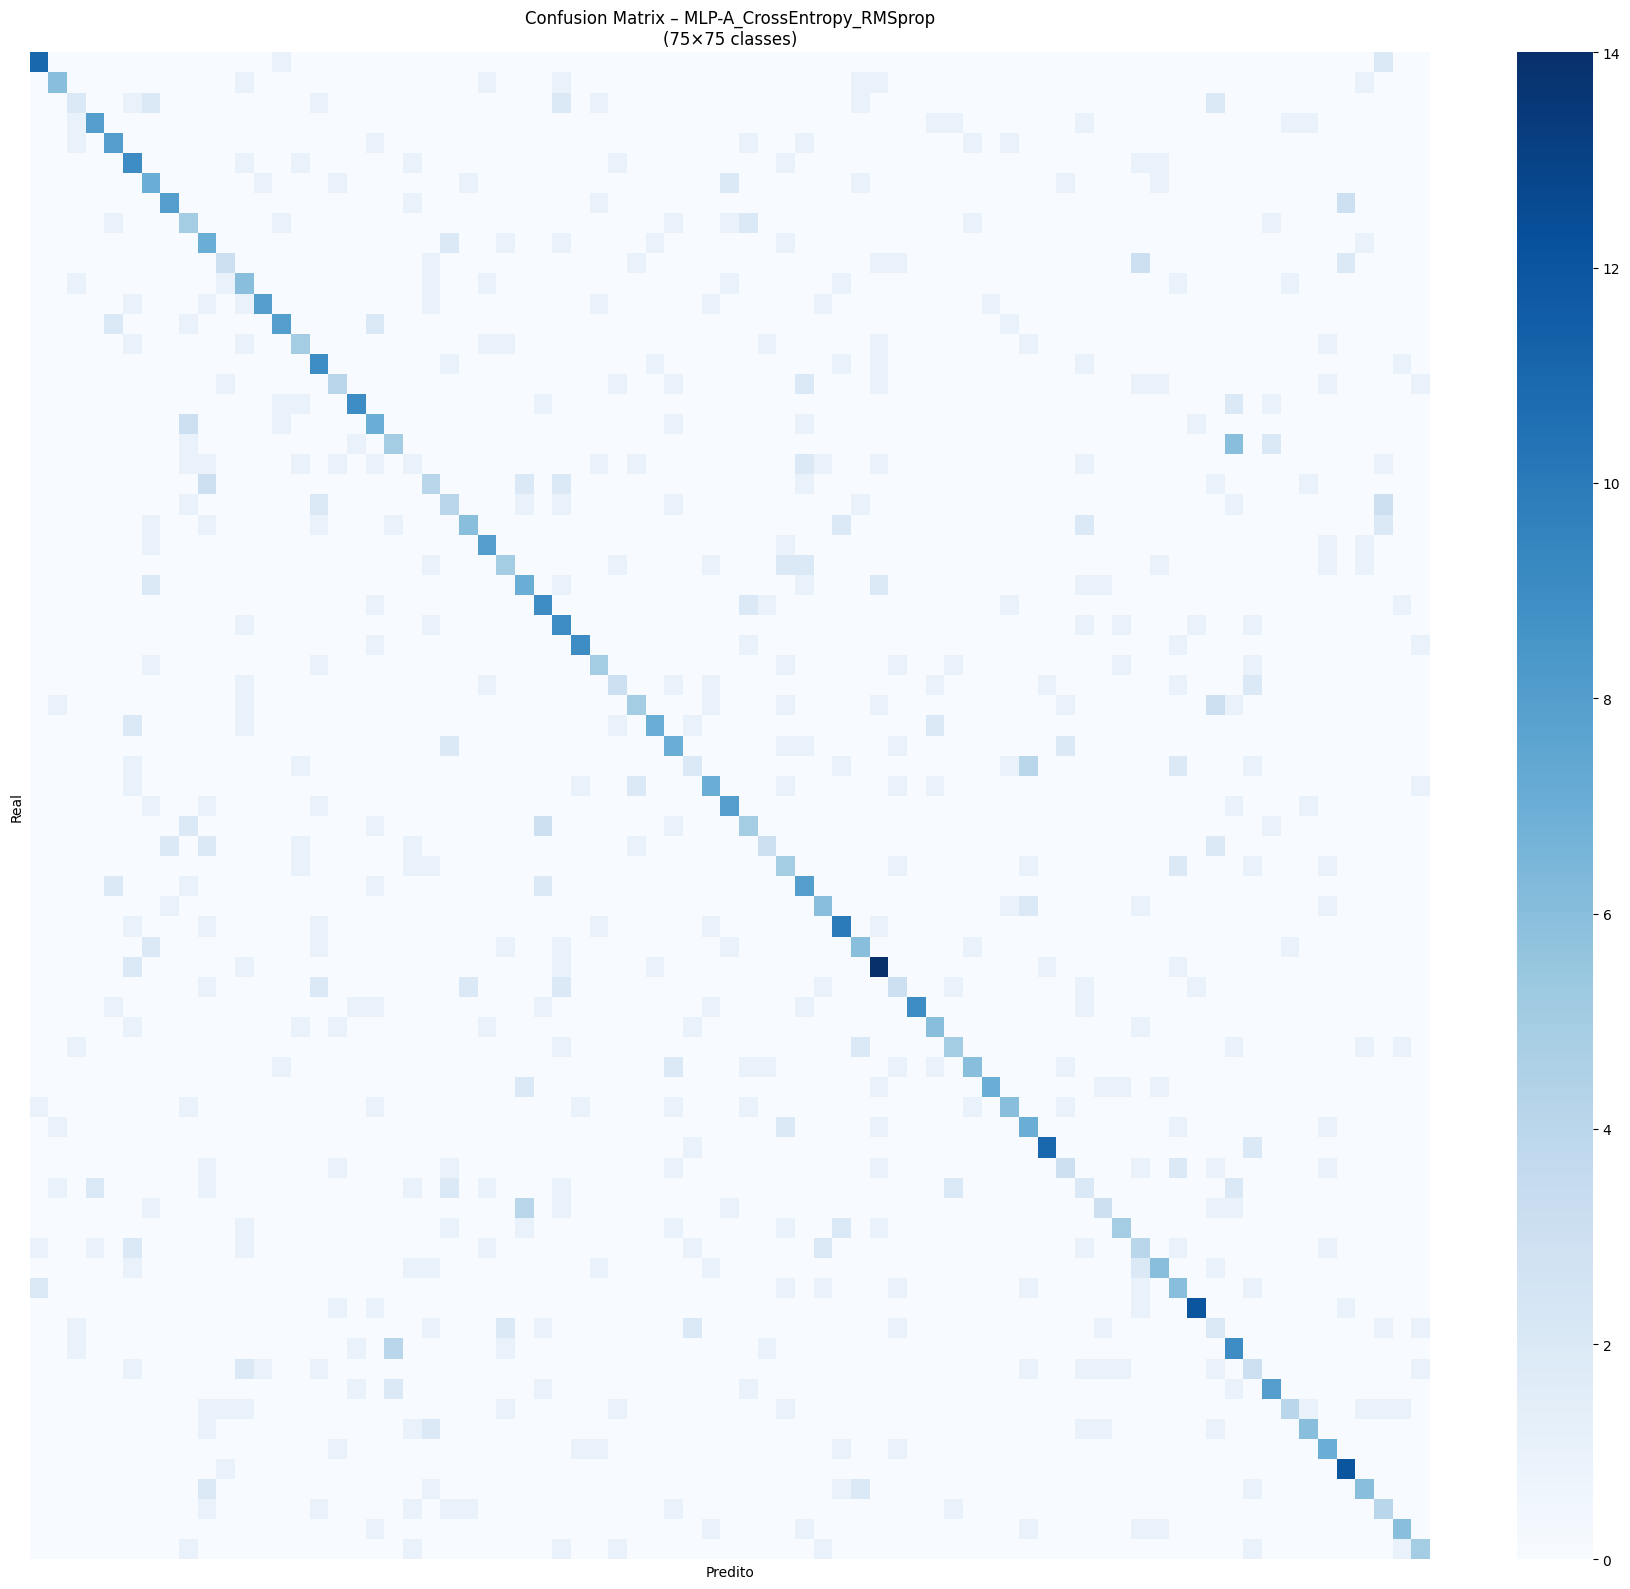

In [23]:
# Selecciona o experimento com maior val_acc
best_key = max(results, key=lambda k: results[k]['val_acc'])
print(f'Melhor experimento: {best_key}  |  Val Acc = {results[best_key]["val_acc"]:.4f}')

preds  = results[best_key]['preds']
labels = results[best_key]['labels']
cm     = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, ax=ax, cmap='Blues', xticklabels=False, yticklabels=False)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix – {best_key}\n(75×75 classes)')
plt.tight_layout()
plt.show()

### 6.5 Classification Report – melhor modelo

In [24]:
print(classification_report(
    labels, preds,
    target_names=classes,
    zero_division=0
))

                           precision    recall  f1-score   support

                   ADONIS       0.73      0.79      0.76        14
AFRICAN GIANT SWALLOWTAIL       0.67      0.50      0.57        12
           AMERICAN SNOOT       0.25      0.17      0.20        12
                    AN 88       0.73      0.57      0.64        14
                  APPOLLO       0.57      0.57      0.57        14
                    ATALA       0.38      0.56      0.45        16
 BANDED ORANGE HELICONIAN       0.39      0.47      0.42        15
           BANDED PEACOCK       0.73      0.62      0.67        13
            BECKERS WHITE       0.29      0.38      0.33        13
         BLACK HAIRSTREAK       0.28      0.50      0.36        14
              BLUE MORPHO       0.43      0.25      0.32        12
        BLUE SPOTTED CROW       0.30      0.43      0.35        14
           BROWN SIPROETA       0.80      0.50      0.62        16
            CABBAGE WHITE       0.62      0.57      0.59     

## 7. Análise e Conclusões

### Um MLP para classificação de imagens
Um MLP **flatten** a imagem antes de a processar, perdendo toda a estrutura espacial 2D. Isto é uma desvantagem importante para imagens naturais, onde padrões locais (texturas, bordas, padrões de asa) são informativos. As CNNs e ResNets exploram precisamente essa estrutura.

### Comparação de losses
- **CrossEntropyLoss**: softmax implícito; penaliza a probabilidade da classe correta de forma contínua; indicada para classificação multi-classe com rótulos duros.
- **MultiMarginLoss**: loss de margem hinge multi-classe; maximiza a margem entre a classe correcta e as outras; tende a ser mais esparsa (zero loss quando a margem já é satisfeita).

### Comparação de optimizadores
- **RMSprop**: adapta o learning rate por parâmetro com base na média das magnitudes recentes dos gradientes; bom para redes recorrentes e problemas não-estacionários.
- **Adam**: combina momento com RMSprop; mais popular em visão; tende a convergir mais rapidamente.

### Limitações do MLP neste problema
- Perde informação espacial (necessária para reconhecimento de espécies)
- Grande número de parâmetros com input de alta dimensão
- Sujeito a overfitting rápido sem regularização adequada
